In [2]:
from os import chdir
from pathlib import Path

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name == "code":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main/code
CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [3]:
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import random
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [4]:
from general.functions import LinearModel, generate_local_data, sample_neighbors, decentralized_gd_with_sampling,  centralized_weighted_gradient_descent

In [5]:
from src.graphs import random_k_out_graph, create_graph, create_cycle_graph,create_scale_free_graph

In [6]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    # For CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # For deterministic behavior (slower)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(0)

In [7]:
def compute_theta_rmse(estimated_theta: torch.Tensor, true_theta: torch.Tensor, data_sizes) -> float:
    assert estimated_theta.shape == true_theta.shape, "Shape mismatch"
    d = true_theta.numel()
    total_n = sum(data_sizes)
    weighted_mse = 0.0
    
    for n_k in data_sizes:
        diff = estimated_theta - true_theta
        mse_k = torch.norm(diff).item() ** 2 / d
        weighted_mse += n_k * mse_k
        
    return (weighted_mse / total_n) ** 0.5

In [8]:
def compute_weighted_theta_rmse(estimated_thetas, true_theta, data_sizes):
    d = true_theta.numel()
    total_n = sum(data_sizes)
    weighted_mse = 0.0

    for theta_k, n_k in zip(estimated_thetas, data_sizes):
        diff = theta_k - true_theta
        mse_k = torch.norm(diff).item() ** 2 / d
        weighted_mse += n_k * mse_k

    return (weighted_mse / total_n) ** 0.5

In [84]:
def plot_rmse_vs_comm_cost(rmse_lists, comm_cost_lists, labels=None, title="RMSE vs Communication Cost", save_path=None):
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(8, 6))
    for i, (rmse_list, comm_list) in enumerate(zip(rmse_lists, comm_cost_lists)):
        cumulative_comm = np.cumsum(comm_list)
        label = labels[i] if labels else f"Method {i+1}"
        plt.plot(cumulative_comm, rmse_list, label=label)

    plt.xlabel("Cumulative Communication Cost (Bytes)")
    plt.ylabel("RMSE")
    plt.xlim(0, 10000) 
    plt.ylim(0, 2) 
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")
    else:
        plt.show()

In [10]:
num_clients = 50
dim = 10
true_beta = torch.ones(dim, 1)
data_n = 200
graph_seed = 1
n_epoch = 100
sample_node = 10

In [11]:
data = [generate_local_data(data_n, true_beta, dim = dim) for _ in range(num_clients)]
loaders = [DataLoader(TensorDataset(X, y), batch_size=32, shuffle=True) for X, y in data]
data_sizes = [len(X) for X, _ in data]

# Random-2-out

In [13]:
# Graph
G = random_k_out_graph(n=num_clients, k=2, seed=graph_seed)

In [14]:
decentral_theta_random2out, rmse_random2out, comm_random2out= decentralized_gd_with_sampling(
    data_loader = loaders, G = G, dim=dim, epochs=100, lr=0.1, sample_size=sample_node,
    true_beta=true_beta, data_sizes=data_sizes
)

In [15]:
global_rmse = compute_weighted_theta_rmse(decentral_theta_random2out, true_beta, data_sizes)

print(f"Decentralized Global RMSE (weighted): {global_rmse:.6f}")

Decentralized Global RMSE (weighted): 0.023445


# Random-5-out

In [17]:
# Graph
G = random_k_out_graph(n=num_clients, k=5, seed=graph_seed)

In [18]:
decentral_theta_random5out,  rmse_random5out, comm_random5out = decentralized_gd_with_sampling(
    data_loader = loaders, G = G, dim=dim, epochs=100, lr=0.1, sample_size=sample_node,
    true_beta=true_beta, data_sizes=data_sizes
)

In [19]:
global_rmse = compute_weighted_theta_rmse(decentral_theta_random5out, true_beta, data_sizes)

print(f"Decentralized Global RMSE (weighted): {global_rmse:.6f}")

Decentralized Global RMSE (weighted): 0.022512


# Cycle

In [21]:
# Graph
G = create_cycle_graph(num_clients)

In [22]:
decentral_theta_cycle,  rmse_cycle, comm_cycle = decentralized_gd_with_sampling(
    data_loader = loaders, G = G, dim=dim, epochs=100, lr=0.1, sample_size=sample_node,
    true_beta=true_beta, data_sizes=data_sizes
)

In [23]:
global_rmse = compute_weighted_theta_rmse(decentral_theta_cycle, true_beta, data_sizes)

print(f"Decentralized Global RMSE (weighted): {global_rmse:.6f}")

Decentralized Global RMSE (weighted): 0.025954


# Scale-Free

In [25]:
# Graph
G = create_scale_free_graph(num_clients) 

In [26]:
decentral_theta_scalefree, rmse_scalefree, comm_scalefree =  decentralized_gd_with_sampling(
    data_loader = loaders, G = G, dim=dim, epochs=100, lr=0.1, sample_size=sample_node,
    true_beta=true_beta, data_sizes=data_sizes
)

In [27]:
global_rmse = compute_weighted_theta_rmse(decentral_theta_scalefree, true_beta, data_sizes)

print(f"Decentralized Global RMSE (weighted): {global_rmse:.6f}")

Decentralized Global RMSE (weighted): 0.027602


# Centralized

In [29]:
# Centralized training
theta_central_local, rmse_central_local, comm_central_local  = centralized_weighted_gradient_descent(
    data_splits = data, dim=dim, epochs=100, lr=0.1, true_beta=true_beta.T, data_sizes = data_sizes,local = True
)


In [30]:
rmse = compute_theta_rmse(theta_central_local, true_beta.T, data_sizes = data_sizes)
print(f"Centralized θ RMSE: {rmse:.6f}")

Centralized θ RMSE: 0.002911


In [31]:
# Centralized training
theta_central, rmse_central, comm_central  = centralized_weighted_gradient_descent(
    data_splits = data, dim=dim, epochs=100, lr=0.1, true_beta=true_beta.T, data_sizes = data_sizes,local = False
)

In [32]:
rmse = compute_theta_rmse(theta_central, true_beta.T, data_sizes = data_sizes)
print(f"Centralized θ RMSE: {rmse:.6f}")

Centralized θ RMSE: 0.000708


Plot saved to rmse_vs_comm_cost.png


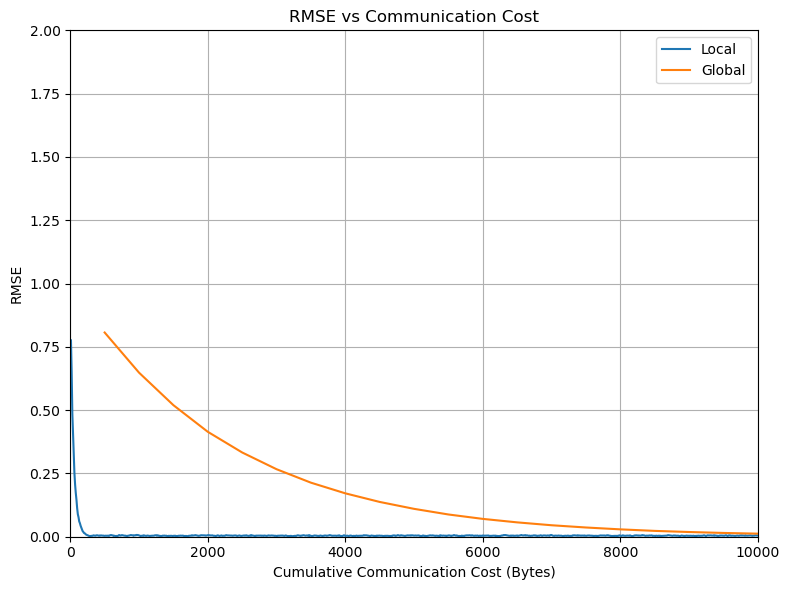

In [86]:
plot_rmse_vs_comm_cost(
    rmse_lists=[ rmse_central_local, rmse_central],
    comm_cost_lists=[comm_central_local, comm_central],
    labels=["Local", "Global"],
    save_path="rmse_vs_comm_cost.png"
)

# Plot

Plot saved to rmse_vs_comm_cost.png


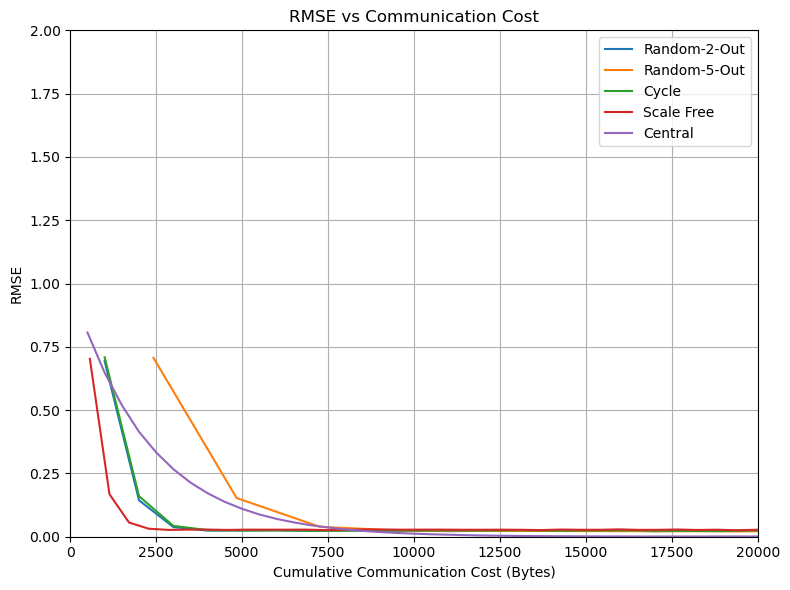

In [77]:
plot_rmse_vs_comm_cost(
    rmse_lists=[ rmse_random2out, rmse_random5out, rmse_cycle, rmse_scalefree, rmse_central],
    comm_cost_lists=[comm_random2out, comm_random5out, comm_cycle, comm_scalefree, comm_central],
    labels=["Random-2-Out", "Random-5-Out", "Cycle", "Scale Free", "Central"],
    save_path="rmse_vs_comm_cost.png"
)

In [36]:
# Graph
G = create_scale_free_graph(num_clients) 

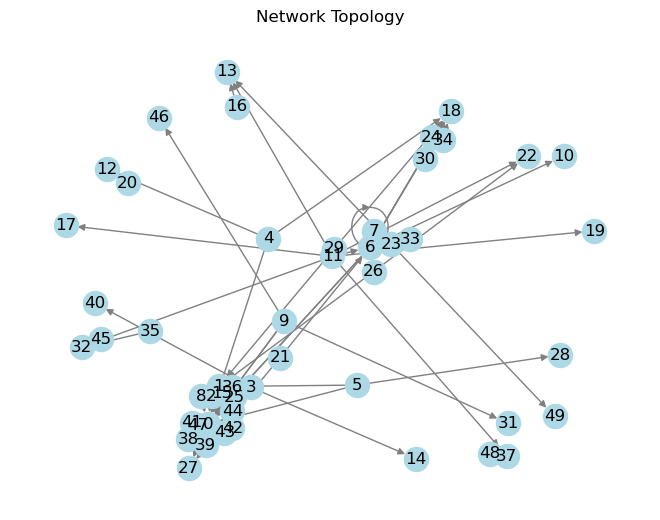

In [37]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)  # or nx.circular_layout(G), nx.kamada_kawai_layout(G), etc.
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Network Topology")
plt.show()

In [38]:
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    print(f"Node {node}: neighbors -> {neighbors}")

Node 0: neighbors -> [1, 27]
Node 1: neighbors -> [2, 0]
Node 2: neighbors -> [0]
Node 3: neighbors -> [0, 14, 40]
Node 4: neighbors -> [0, 12, 18]
Node 5: neighbors -> [1, 0, 28]
Node 6: neighbors -> [6, 10, 0, 18]
Node 7: neighbors -> [6]
Node 8: neighbors -> [0]
Node 9: neighbors -> [0, 31, 46]
Node 10: neighbors -> []
Node 11: neighbors -> [6, 13, 17, 19, 22, 32, 37]
Node 12: neighbors -> []
Node 13: neighbors -> []
Node 14: neighbors -> []
Node 15: neighbors -> [0]
Node 16: neighbors -> [13]
Node 17: neighbors -> []
Node 18: neighbors -> []
Node 19: neighbors -> []
Node 20: neighbors -> [12]
Node 21: neighbors -> [6, 27]
Node 22: neighbors -> []
Node 23: neighbors -> [13, 49]
Node 24: neighbors -> [18]
Node 25: neighbors -> [0]
Node 26: neighbors -> [22, 1]
Node 27: neighbors -> []
Node 28: neighbors -> []
Node 29: neighbors -> [18, 1]
Node 30: neighbors -> [18]
Node 31: neighbors -> []
Node 32: neighbors -> []
Node 33: neighbors -> [23]
Node 34: neighbors -> [18]
Node 35: neighbo